<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
#pip install shap

In [13]:
#pip install https://github.com/matplotlib/mpl_finance/archive/master.zip

In [14]:
!pip install --upgrade mplfinance

In [15]:
#pip install --upgrade mplfinance

In [16]:
# import tensorflow as tf
# tf.test.gpu_device_name()

In [17]:
# from google.colab import drive
# drive.mount('/content/drive')

In [21]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [22]:
!pip install yfinance

### Загрузка реальных данных (Forex, Gold, Crypto)
Ниже приведен код для загрузки данных. Вы можете заменить тикеры на нужные вам (например, 'EURUSD=X', 'GC=F' для золота, 'BTC-USD' для крипты).

In [23]:
import yfinance as yf

# Пример: EUR/USD (Форекс), Gold (Золото), BTC (Крипта)
tickers = ['EURUSD=X', 'GC=F', 'BTC-USD']
data = yf.download(tickers[0], period='1y', interval='1h')

# Приведение данных к формату вашего датасета
my_dataset = data[['Open', 'High', 'Low', 'Close']].copy()
my_dataset.columns = ['<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>']
display(my_dataset.head())

/tmp/ipykernel_1681/755388152.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers[0], period='1y', interval='1h')
[*********************100%***********************]  1 of 1 completed


,<OPEN>,<HIGH>,<LOW>,<CLOSE>
Datetime,,,,
2025-05-06 08:00:00+00:00,1.134044,1.135074,1.132888,1.133016
2025-05-06 09:00:00+00:00,1.133016,1.133273,1.130966,1.131350
2025-05-06 10:00:00+00:00,1.131478,1.132888,1.131350,1.132888
2025-05-06 11:00:00+00:00,1.132759,1.133787,1.132759,1.132888
2025-05-06 12:00:00+00:00,1.133144,1.134559,1.132246,1.134559


In [18]:
import matplotlib
import numpy as np
import pandas as pd
import itertools
import sklearn
import keras
import time
import shap


from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv1D, LSTM
# The CuDNNLSTM layer is deprecated. Use LSTM with recurrent_activation='sigmoid'.
# from tensorflow.keras.layers import CuDNNLSTM
from matplotlib import pyplot as plt
from sklearn import preprocessing

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
#from  mpl_finance import candlestick_ohlc
from mplfinance.original_flavor import candlestick_ohlc


print('Numpy version: ' + np.__version__)
print('Pandas version: ' + pd.__version__)
print('Matplotlib version: ' + matplotlib.__version__)
print('Sklearn version: ' + sklearn.__version__)
print('Keras version: ' + keras.__version__)

Numpy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Sklearn version: 1.6.1
Keras version: 3.13.2


In [19]:
class MeasureTime:
    def __init__(self):
        self.start = time.time()
    def kill(self):
        print ('Time elapsed: ' + time.strftime("%H:%M:%S", time.gmtime(time.time()-self.start)))
        del self
Notebook_timer = MeasureTime()
Notebook_timer.kill()

Time elapsed: 00:00:00


In [24]:
# my_dataset уже содержит данные из yfinance
print("Используются реальные данные из yfinance:")
display(my_dataset.head(5))

Используются реальные данные из yfinance:


,<OPEN>,<HIGH>,<LOW>,<CLOSE>
Datetime,,,,
2025-05-06 08:00:00+00:00,1.134044,1.135074,1.132888,1.133016
2025-05-06 09:00:00+00:00,1.133016,1.133273,1.130966,1.131350
2025-05-06 10:00:00+00:00,1.131478,1.132888,1.131350,1.132888
2025-05-06 11:00:00+00:00,1.132759,1.133787,1.132759,1.132888
2025-05-06 12:00:00+00:00,1.133144,1.134559,1.132246,1.134559


In [ ]:
def graph_data_ohlc(dataset):
    fig = plt.figure()
    ax1 = plt.subplot2grid((1,1), (0,0))
    closep=dataset[:,[3]]
    highp=dataset[:,[1]]
    lowp=dataset[:,[2]]
    openp=dataset[:,[0]]
    date=range(len(closep))

    x = 0
    y = len(date)
    ohlc = []
    while x < y:
        append_me = date[x], openp[x], highp[x], lowp[x], closep[x]
        ohlc.append(append_me)
        x+=1
    candlestick_ohlc(ax1, ohlc, width=0.4, colorup='#77d879', colordown='#db3f3f')
    for label in ax1.xaxis.get_ticklabels():
        label.set_rotation(45)
    ax1.xaxis.set_major_locator(mticker.MaxNLocator(10))
    ax1.grid(True)
    plt.xlabel('Candle')
    plt.ylabel('Price')
    plt.title('Candlestick sample representation')

    plt.subplots_adjust(left=0.09, bottom=0.20, right=0.94, top=0.90, wspace=0.2, hspace=0)
    plt.show()

In [ ]:
graph_data_ohlc(my_dataset.tail(1000).values)

In [ ]:
def my_generator(data,lookback):
    final_output = []
    counter = 0
    first_row = 0
    arr = np.empty((1,lookback,4), int)
    for a in range(len(data)-lookback):
        temp_list = []
        for candle in data[first_row:first_row+lookback]:
            temp_list.append(candle)
        temp_list2 = np.asarray(temp_list)
        templist3 = [temp_list2]
        templist4 = np.asarray(templist3)
        arr = np.append(arr, templist4, axis=0)
        first_row=first_row+1
    return arr

In [ ]:
cell_timer = MeasureTime()
three_dim_sequence = np.asarray(my_generator(my_dataset.values[1:],3))
cell_timer.kill()

In [ ]:
three_dim_sequence.shape

In [ ]:
counter=0
for candle in three_dim_sequence[1000:1005]:
    counter=counter+1
    print('Step ' + str(counter))
    graph_data_ohlc(candle)

In [ ]:
def ohlc_to_candlestick(conversion_array):
    candlestick_data = [0,0,0,0]

    if conversion_array[3]>conversion_array[0]:
        candle_type=1
        wicks_up=conversion_array[1]-conversion_array[3]
        wicks_down=conversion_array[2]-conversion_array[0]
        body_size=conversion_array[3]-conversion_array[0]

    else:
        candle_type=0
        wicks_up=conversion_array[1]-conversion_array[0]
        wicks_down=conversion_array[2]-conversion_array[3]
        body_size=conversion_array[1]-conversion_array[3]


    if wicks_up < 0:wicks_up=wicks_up*(-1)
    if wicks_down < 0:wicks_down=wicks_down*(-1)
    if body_size < 0:body_size=body_size*(-1)
    candlestick_data[0]=candle_type
    candlestick_data[1]=round(round(wicks_up,5)*10000,2)
    candlestick_data[2]=round(round(wicks_down,5)*10000,2)
    candlestick_data[3]=round(round(body_size,5)*10000,2)

    return candlestick_data

In [ ]:
cell_timer = MeasureTime()
one_candle_data_ohlc=three_dim_sequence[1000:1010][5][1]
cell_timer.kill()

In [ ]:
one_candle_data_ohlc

In [ ]:
one_candle_data_ohlc_candle=ohlc_to_candlestick(one_candle_data_ohlc)

In [ ]:
def my_generator_candle(data,lookback):
    first_row = 0
    arr = np.empty((1,lookback,4), int)
    for a in range(len(data)-lookback):
        temp_list = []
        for candle in data[first_row:first_row+lookback]:
            converted_data = ohlc_to_candlestick(candle)
            temp_list.append(converted_data)
        temp_list2 = np.asarray(temp_list)
        templist3 = [temp_list2]
        templist4 = np.asarray(templist3)
        arr = np.append(arr, templist4, axis=0)
        first_row=first_row+1
    return arr

In [ ]:
three_dim_sequence_candle=my_generator_candle(my_dataset.values[1:],3)

In [ ]:
three_dim_sequence_candle[5000:5005]

In [ ]:
def my_generator_candle_X_Y(data,lookback,MinMax = False):
    if MinMax==True:scaler = preprocessing.MinMaxScaler()
    first_row = 0
    arr = np.empty((0,lookback,4))
    arr3 = np.empty((0,lookback,4))
    Y_list = []
    for a in range(len(data)-lookback):
        temp_list = []
        temp_list_raw = []
        for candle in data[first_row:first_row+lookback]:
            converted_data = ohlc_to_candlestick(candle)
            temp_list.append(converted_data)
            temp_list_raw.append(candle)
        temp_list3 = [np.asarray(temp_list)]
        templist4 = np.asarray(temp_list3)

        if MinMax==True:
            templist99 = scaler.fit_transform(templist4[0])
            arr = np.append(arr, [templist99], axis=0)
        else:
            arr = np.append(arr, templist4, axis=0)

        temp_list7 = [np.asarray(temp_list_raw)]
        templist8 = np.asarray(temp_list7)
        arr3 = np.append(arr3, templist8, axis=0)

        converted_data_prediction = ohlc_to_candlestick(data[first_row+lookback])
        Prediction = converted_data_prediction[0]
        Y_list.append(Prediction)

        first_row=first_row+1

    arr2 = np.asarray(Y_list)

    return arr,arr2,arr3

In [ ]:
cell_timer = MeasureTime()
X,Y, X_raw = my_generator_candle_X_Y(my_dataset.values,3,MinMax=False)
cell_timer.kill()

In [ ]:
print('Shape of X ' + str(X.shape))
print('Shape of Y ' + str(Y.shape))
print('Shape of X raw ohlc ' + str(X_raw.shape))

In [ ]:
X[653]

In [ ]:
Y[653]

In [ ]:
X_raw[653]

In [ ]:
unique, counts = np.unique(Y, return_counts=True)
predictions_type = dict(zip(unique, counts))
print('Bull: ' + str((predictions_type[1])) + ' percent: ' + str(round((predictions_type[1]*100)/len(Y),2)) + '%')
print('Bear: ' + str((predictions_type[0])) + ' percent: ' + str(round((predictions_type[0]*100)/len(Y),2)) + '%')
print('Total: ' + str(len(Y)))

In [ ]:
for a in range(5):
    b=a+1000
    if Y[b] == 1:print('Correct prediction would be Bullish ---^')
    if Y[b] == 0:print('Correct prediction would be Bearish ---v')
    graph_data_ohlc(X_raw[b])

In [ ]:
from keras import layers
from tensorflow.keras.optimizers import RMSprop


model = Sequential()
model.add(layers.LSTM(units = 12,return_sequences=True, input_shape = (None, X.shape[-1])))
model.add(layers.LSTM(units = 24))
model.add(layers.Dense(units = 1,activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

In [ ]:
model.summary()

In [30]:
cell_timer = MeasureTime()
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

def ohlc_to_candlestick(conversion_array):
    candlestick_data = [0,0,0,0]
    if conversion_array[3]>conversion_array[0]:
        candle_type=1
        wicks_up=conversion_array[1]-conversion_array[3]
        wicks_down=conversion_array[2]-conversion_array[0]
        body_size=conversion_array[3]-conversion_array[0]
    else:
        candle_type=0
        wicks_up=conversion_array[1]-conversion_array[0]
        wicks_down=conversion_array[2]-conversion_array[3]
        body_size=conversion_array[1]-conversion_array[3]
    if wicks_up < 0:wicks_up=wicks_up*(-1)
    if wicks_down < 0:wicks_down=wicks_down*(-1)
    if body_size < 0:body_size=body_size*(-1)
    candlestick_data[0]=candle_type
    candlestick_data[1]=round(round(wicks_up,5)*10000,2)
    candlestick_data[2]=round(round(wicks_down,5)*10000,2)
    candlestick_data[3]=round(round(body_size,5)*10000,2)
    return candlestick_data

def my_generator_candle_X_Y(data,lookback,MinMax = False):
    if MinMax==True:scaler = preprocessing.MinMaxScaler()
    first_row = 0
    arr = np.empty((0,lookback,4))
    arr3 = np.empty((0,lookback,4))
    Y_list = []
    for a in range(len(data)-lookback):
        temp_list = []
        temp_list_raw = []
        for candle in data[first_row:first_row+lookback]:
            converted_data = ohlc_to_candlestick(candle)
            temp_list.append(converted_data)
            temp_list_raw.append(candle)
        temp_list3 = [np.asarray(temp_list)]
        templist4 = np.asarray(temp_list3)
        if MinMax==True:
            templist99 = scaler.fit_transform(templist4[0])
            arr = np.append(arr, [templist99], axis=0)
        else:
            arr = np.append(arr, templist4, axis=0)
        temp_list7 = [np.asarray(temp_list_raw)]
        templist8 = np.asarray(temp_list7)
        arr3 = np.append(arr3, templist8, axis=0)
        converted_data_prediction = ohlc_to_candlestick(data[first_row+lookback])
        Prediction = converted_data_prediction[0]
        Y_list.append(Prediction)
        first_row=first_row+1
    arr2 = np.asarray(Y_list)
    return arr,arr2,arr3

# 1. Генерируем X, Y и X_raw
X, Y, X_raw = my_generator_candle_X_Y(my_dataset.values, 3, MinMax=False)

# 2. Разделяем на выборки
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X, Y, test_size=0.5, shuffle=False)
X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.5, shuffle=False)
X_train_raw, X_val_and_test_raw = train_test_split(X_raw, test_size=0.5, shuffle=False)
X_val_raw, X_test_raw = train_test_split(X_val_and_test_raw, test_size=0.5, shuffle=False)

print(f'Данные подготовлены. Размер X_train: {X_train.shape}')
cell_timer.kill()

Данные подготовлены. Размер X_train: (3084, 3, 4)
Time elapsed: 00:00:00


In [ ]:
print('Training data: ' + 'X Input shape: ' + str(X_train.shape) + ', ' + 'Y Output shape: ' + str(Y_train.shape) + ', ' + 'datetime shape: ' + str(Y_train.shape))
print('Validation data: ' + 'X Input shape: ' + str(X_val.shape) + ', ' + 'Y Output shape: ' + str(Y_val.shape) + ', ' + 'datetime shape: ' + str(Y_val.shape))
print('Test data: ' + 'X Input shape: ' + str(X_test.shape) + ', ' + 'Y Output shape: ' + str(Y_test.shape) + ', ' + 'datetime shape: ' + str(Y_test.shape))

In [ ]:
cell_timer = MeasureTime()
history = model.fit(X_train, Y_train,batch_size=500, epochs=13,validation_data=(X_val, Y_val))
cell_timer.kill()

In [ ]:
# Chart 1 - Model Loss
#plt.subplot(331)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()


# Chart 2 - Model Accuracy
#plt.subplot(332)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, Y_test)
print('Test accuracy:', test_acc)

In [ ]:
cell_timer = MeasureTime()
counter = 0
won = 0
lost = 0
test = model.predict(X_test)
alpha_distance = 0.35

for a in test:
    #print(a)
    if a > (1-alpha_distance) or a < alpha_distance :
        print(a)
        if Y_test[counter] == 1:print('Correct prediction is Bullish')
        if Y_test[counter] == 0:print('Correct prediction is Bearish')
        if a > (1-alpha_distance):print('Model prediction is Bullish')
        if a < alpha_distance:print('Model prediction is Bearish')

        if (a > (1-alpha_distance) and Y_test[counter] == 1) or (a < alpha_distance and Y_test[counter] == 0):
            won=won+1
            print('WON')
        else:
            print('LOST')
            lost=lost+1

        graph_data_ohlc(X_test_raw[counter])

    counter=counter+1
print('Won: ' + str(won) + ' Lost: ' + str(lost))
# print('Success rate: ' + str(round((won*100)/(won+lost),2)) + '%')
cell_timer.kill()

In [26]:
def simple_backtest(predictions, real_ohlc, initial_balance=10000, trade_size=1000):
    balance = initial_balance
    equity_curve = [balance]

    for i in range(len(predictions)):
        prediction = predictions[i]
        open_price = real_ohlc[i][0]
        close_price = real_ohlc[i][3]

        if prediction > 0.5:
            profit = (close_price - open_price) * trade_size
            balance += profit
        else:
            profit = (open_price - close_price) * trade_size
            balance += profit

        equity_curve.append(balance)

    return balance, equity_curve

# Ensure data is split before predicting
if 'X_test' in globals():
    test_predictions = model.predict(X_test)
    final_bal, curve = simple_backtest(test_predictions, X_test_raw)

    print(f'Initial Balance: 10000')
    print(f'Final Balance: {final_bal:.2f}')
    print(f'Total Profit/Loss: {final_bal - 10000:.2f}')

    plt.figure(figsize=(10,6))
    plt.plot(curve)
    plt.title('Equity Curve - Simple Backtest')
    plt.xlabel('Trade Number')
    plt.ylabel('Balance')
    plt.grid(True)
    plt.show()
else:
    print('Error: X_test is not defined. Please run the cell where train_test_split is performed.')

Error: X_test is not defined. Please run the cell where train_test_split is performed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Начинаю обучение модели...
Обучение завершено.
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Начальный баланс: 10000
Конечный баланс: 10064.71
Прибыль/Убыток: 64.71


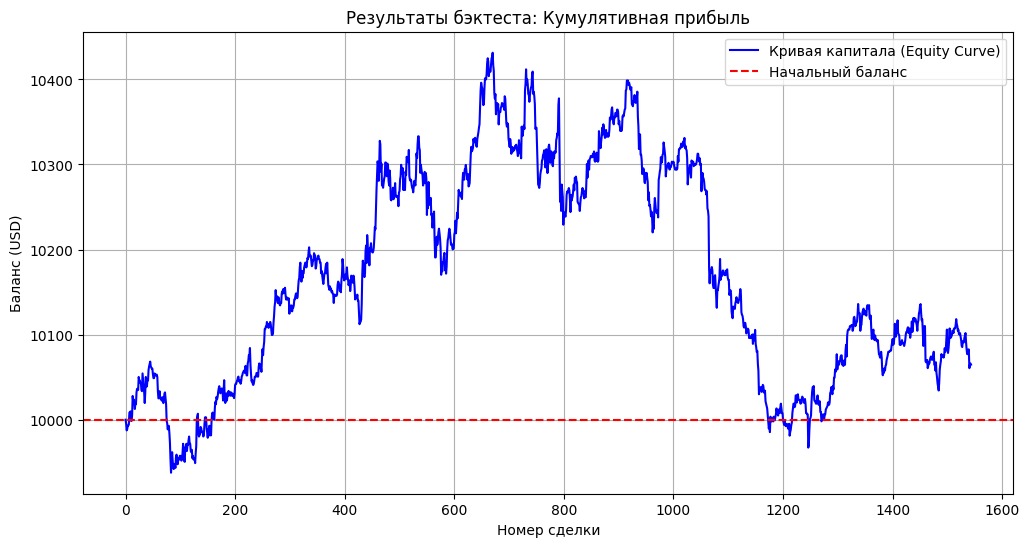

In [32]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
import matplotlib.pyplot as plt

# 1. Определение архитектуры модели
model = Sequential()
model.add(LSTM(units=12, return_sequences=True, input_shape=(3, 4)))
model.add(LSTM(units=24))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

# 2. Обучение модели
print("Начинаю обучение модели...")
history = model.fit(X_train, Y_train, batch_size=500, epochs=10, validation_data=(X_val, Y_val), verbose=0)
print("Обучение завершено.")

# 3. Функция бэктеста
def simple_backtest(predictions, real_ohlc, initial_balance=10000, trade_size=10000):
    balance = initial_balance
    equity_curve = [balance]
    for i in range(len(predictions)):
        prediction = predictions[i]
        open_price = real_ohlc[i][-1][0]
        close_price = real_ohlc[i][-1][3]
        if prediction > 0.5: # Модель предсказывает рост
            profit = (close_price - open_price) * trade_size
        else: # Модель предсказывает падение
            profit = (open_price - close_price) * trade_size
        balance += profit
        equity_curve.append(balance)
    return balance, equity_curve

# 4. Предсказание и расчет результатов
test_predictions = model.predict(X_test)
final_bal, curve = simple_backtest(test_predictions, X_test_raw)

print(f'Начальный баланс: 10000')
print(f'Конечный баланс: {final_bal:.2f}')
print(f'Прибыль/Убыток: {final_bal - 10000:.2f}')

# 5. Визуализация
plt.figure(figsize=(12, 6))
plt.plot(curve, label='Кривая капитала (Equity Curve)', color='blue')
plt.axhline(y=10000, color='r', linestyle='--', label='Начальный баланс')
plt.title('Результаты бэктеста: Кумулятивная прибыль')
plt.xlabel('Номер сделки')
plt.ylabel('Баланс (USD)')
plt.legend()
plt.grid(True)
plt.show()